In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
from dmri.simulators import BallStickZeppelinNoise
from dmri.simulators.acquisition_scheme import acquisition_scheme
from flax import nnx



sim_type = BallStickZeppelinNoise
ball_stick = sim_type.from_theta(np.random.randn(sim_type.theta_dim))

/root/simformer_model_selection/dmri/dmri/simulators/sphereical_distributions.py:27: UserWarning: Pass ['name'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  sphere_default = get_sphere("symmetric724")
/root/simformer_model_selection/dmri/dmri/simulators/sphereical_distributions.py:30: UserWarning: Pass ['name'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  big_sphere = get_sphere("repulsion724")


In [3]:

@jax.jit
def simulator(rng):
    rng0, rng1, rng2, rng3, rng4, rng5 = jax.random.split(rng, 6)
    rng0_1, rng0_2 = jax.random.split(rng0)
    bvals1 = jax.random.choice(rng0_1, jnp.array(list(range(0, 2100, 100))), shape=(160,))
    bvals1 = jnp.sort(bvals1)
    bvals2 = jnp.array([0]*10 + [2000]*150)
    bvals = jax.random.choice(rng0_2, jnp.stack([bvals1, bvals2], axis=0))
    bvecs = jax.random.normal(rng3, shape=(160, 3))
    bvecs = bvecs / jnp.linalg.norm(bvecs, axis=-1, keepdims=True)
    acq = acquisition_scheme(bvals, bvecs)
    theta = jax.random.normal(rng1, shape=(sim_type.theta_dim,))
    model_mask = jax.random.bernoulli(rng2, p=0.5, shape=(len(sim_type.model_types)))
    # This needs to have only one entry
    model_noise_idx = jax.random.randint(rng4, minval=0, maxval=len(sim_type.noise_types), shape=(1,))
    model_noise_mask = jnp.zeros(len(sim_type.noise_types), dtype=jnp.bool)
    model_noise_mask = model_noise_mask.at[model_noise_idx].set(True)
    model_mask = jnp.concatenate([model_mask, model_noise_mask], axis=-1)
    #model_mask = jnp.array([True, True, True])
    ball_stick = sim_type.from_theta(theta, model_mask=model_mask)

    x_o = ball_stick.signal(acq, rng=rng5)
    return model_mask, theta, x_o, acq


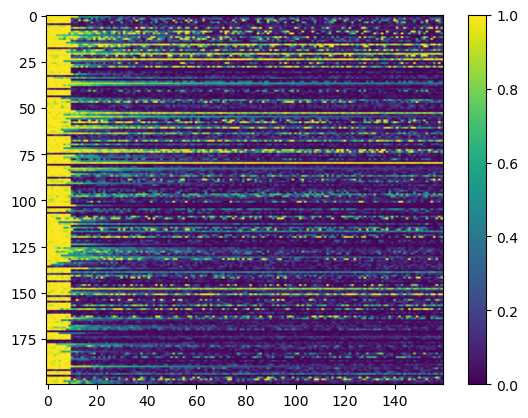

In [4]:
masks, theta, x_o, acq = jax.vmap(simulator)(jax.random.split(jax.random.PRNGKey(0), num=200))

plt.imshow(x_o, aspect='auto', vmin=0, vmax=1)
plt.colorbar()

In [5]:
from dmri.nn.dmri_reconstruction_model import DMRIInferenceModel, DMRIInferenceModelConfig

cfg = DMRIInferenceModelConfig(sim_type)

model = DMRIInferenceModel(cfg, nnx.Rngs(0))

params = nnx.state(model, nnx.Param)


In [6]:
nnx.display(model)

In [267]:
import optax


optimizer = optax.chain(optax.adaptive_grad_clip(50.), optax.ema(0.05), optax.adamw(5e-4))

opt_state = optimizer.init(params)


In [268]:

def loss_fn(params, data, rng):
    components, thetas,  xs, bvals, bvecs = data

    return model.loss_fn(params, rng,model_mask=components, theta=thetas, x=xs,bvals=bvals, bvecs=bvecs).sum()


@jax.jit
def update(params, opt_state, data, rng):
    loss, grads = jax.value_and_grad(loss_fn)(params, data, rng)
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state, loss

In [269]:
batch_simulator = jax.jit(jax.vmap(simulator))

In [270]:
key = jax.random.PRNGKey(42)
for i in range(100):
    key, subkey1 = jax.random.split(key, 2)
    masks, thetas, x_os, acq = batch_simulator(jax.random.split(subkey1, 2**16))
    l = 0
    for j in range(100):
        key, subkey2 = jax.random.split(key, 2)
        idx = jax.random.randint(subkey2, (256,), 0, 2**16)
        masks_batch, thetas_batch, x_os_batch, bvals_batch, bvecs_batch = masks[idx], thetas[idx], x_os[idx], acq.bvals[idx], acq.bvecs[idx]
        params, opt_state, loss = update(params, opt_state, (masks_batch, thetas_batch, x_os_batch, bvals_batch, bvecs_batch), subkey2)
        l += loss
    print(l/100)

(0, 1, 2, 3, 4)
3.739957
3.7254994
3.711863
3.6925807
3.7115688
3.7029533
3.6892354
3.7021596
3.7072275
3.708408
3.7195804
3.7379837
3.6888487
3.688639
3.7022023
3.699936
3.724193
3.705836
3.719426
3.7129073
3.716446
3.714132
3.7004657
3.7192018
3.6974688
3.698865
3.7062416
3.6971505


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7f0b0f6e4d10>>
Traceback (most recent call last):
  File "/root/miniconda3/envs/dipy/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


3.7096303
3.6907833
3.6951108
3.7240787
3.6996212
3.7084816
3.713414
3.7093096
3.6841507
3.6996918
3.6947792
3.7089484
3.703327
3.7056973
3.6805403
3.696566
3.6926327
3.6911166
3.7090719
3.7066793
3.6889608
3.6973488
3.6926885
3.684915
3.687342
3.6960464
3.7056715
3.6932166
3.6878781
3.699501
3.6911154
3.6841757
3.6944127
3.685519
3.7025914
3.6856647
3.8323812
3.7246878
3.7021334
3.697486
3.709022
3.697157
3.686685
3.7143114
3.6858501
3.6897824
3.6919577
3.6631942
3.679932
3.679713
3.6734397
3.6707811
3.684999
3.6804745
3.6810942
3.6853764
3.686431
3.6991682
3.6712599
3.6886525
3.6872551
3.6897774
3.6657803
3.6727655
3.681137
3.6715546
3.6889775
3.6982086
3.684915
3.6571734
3.6945293
3.6983538


In [271]:
nnx.update(model, params)

In [272]:
# import pickle

# with open('params_small.pkl', 'wb') as f:
#     pickle.dump(params, f)

In [7]:
import pickle
with open('params_small.pkl', 'rb') as f:
    params = pickle.load(f)
nnx.update(model, params)

In [274]:
masks, thetas, x_os, acq = batch_simulator(jax.random.split(jax.random.key(0), 100))

In [275]:
idx = 15

In [276]:
mask = jax.vmap(model.sample_mask, in_axes=(0,None,None, None))(jax.random.split(jax.random.key(0), 128), acq.bvals[idx], acq.bvecs[idx], x_os[idx])

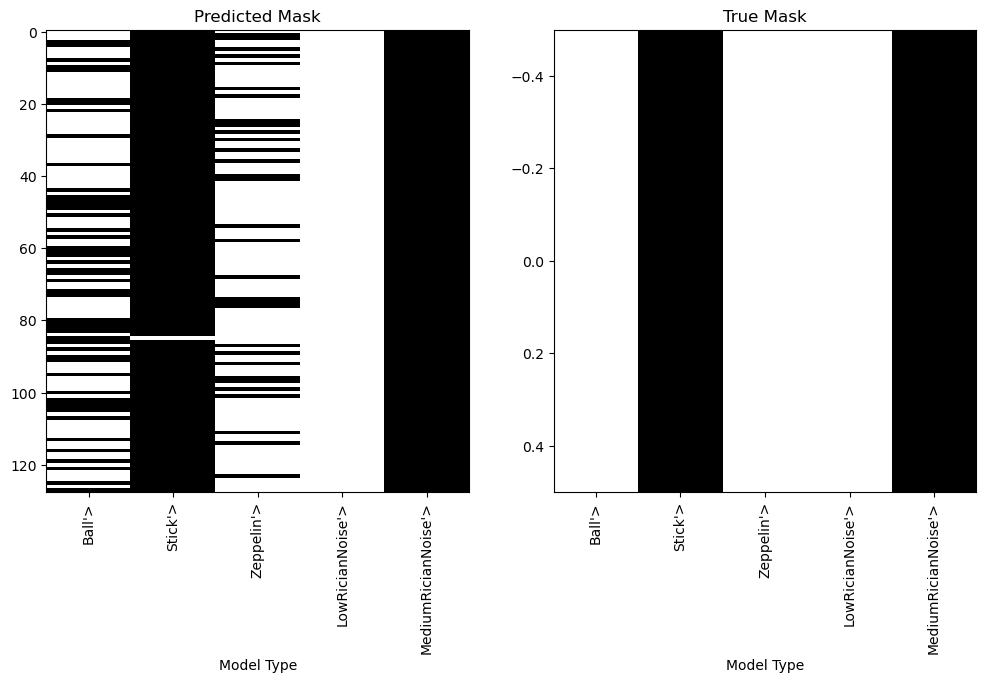

In [76]:
plt.figure(figsize=(12, 6))

# Plot predicted mask
plt.subplot(1, 2, 1)
plt.imshow(mask, aspect='auto', cmap='gray', vmin=0, vmax=1)
plt.title('Predicted Mask')
plt.xlabel('Model Type')
plt.xticks(range(len(sim_type.model_types) + len(sim_type.noise_types)), [str(m).split(".")[-1] for m in sim_type.model_types] + [str(m).split(".")[-1] for m in sim_type.noise_types], rotation=90)

# Plot true mask
mask_true = masks[idx]
plt.subplot(1, 2, 2)
plt.imshow(mask_true[None], aspect='auto', cmap='gray', vmin=0, vmax=1)
plt.title('True Mask')
plt.xlabel('Model Type')
plt.xticks(range(len(sim_type.model_types) + len(sim_type.noise_types)), [str(m).split(".")[-1] for m in sim_type.model_types] + [str(m).split(".")[-1] for m in sim_type.noise_types], rotation=90)

plt.show()

In [277]:
from functools import partial

In [278]:
thetas_post = jax.vmap(partial(model.sample_theta, num_steps=128, max_noise=40), in_axes=(0,None,None, None, None))(jax.random.split(jax.random.key(0), 1024), acq.bvals[idx], acq.bvecs[idx], x_os[idx],masks[idx])

(0, 1, 2, 3, 4)


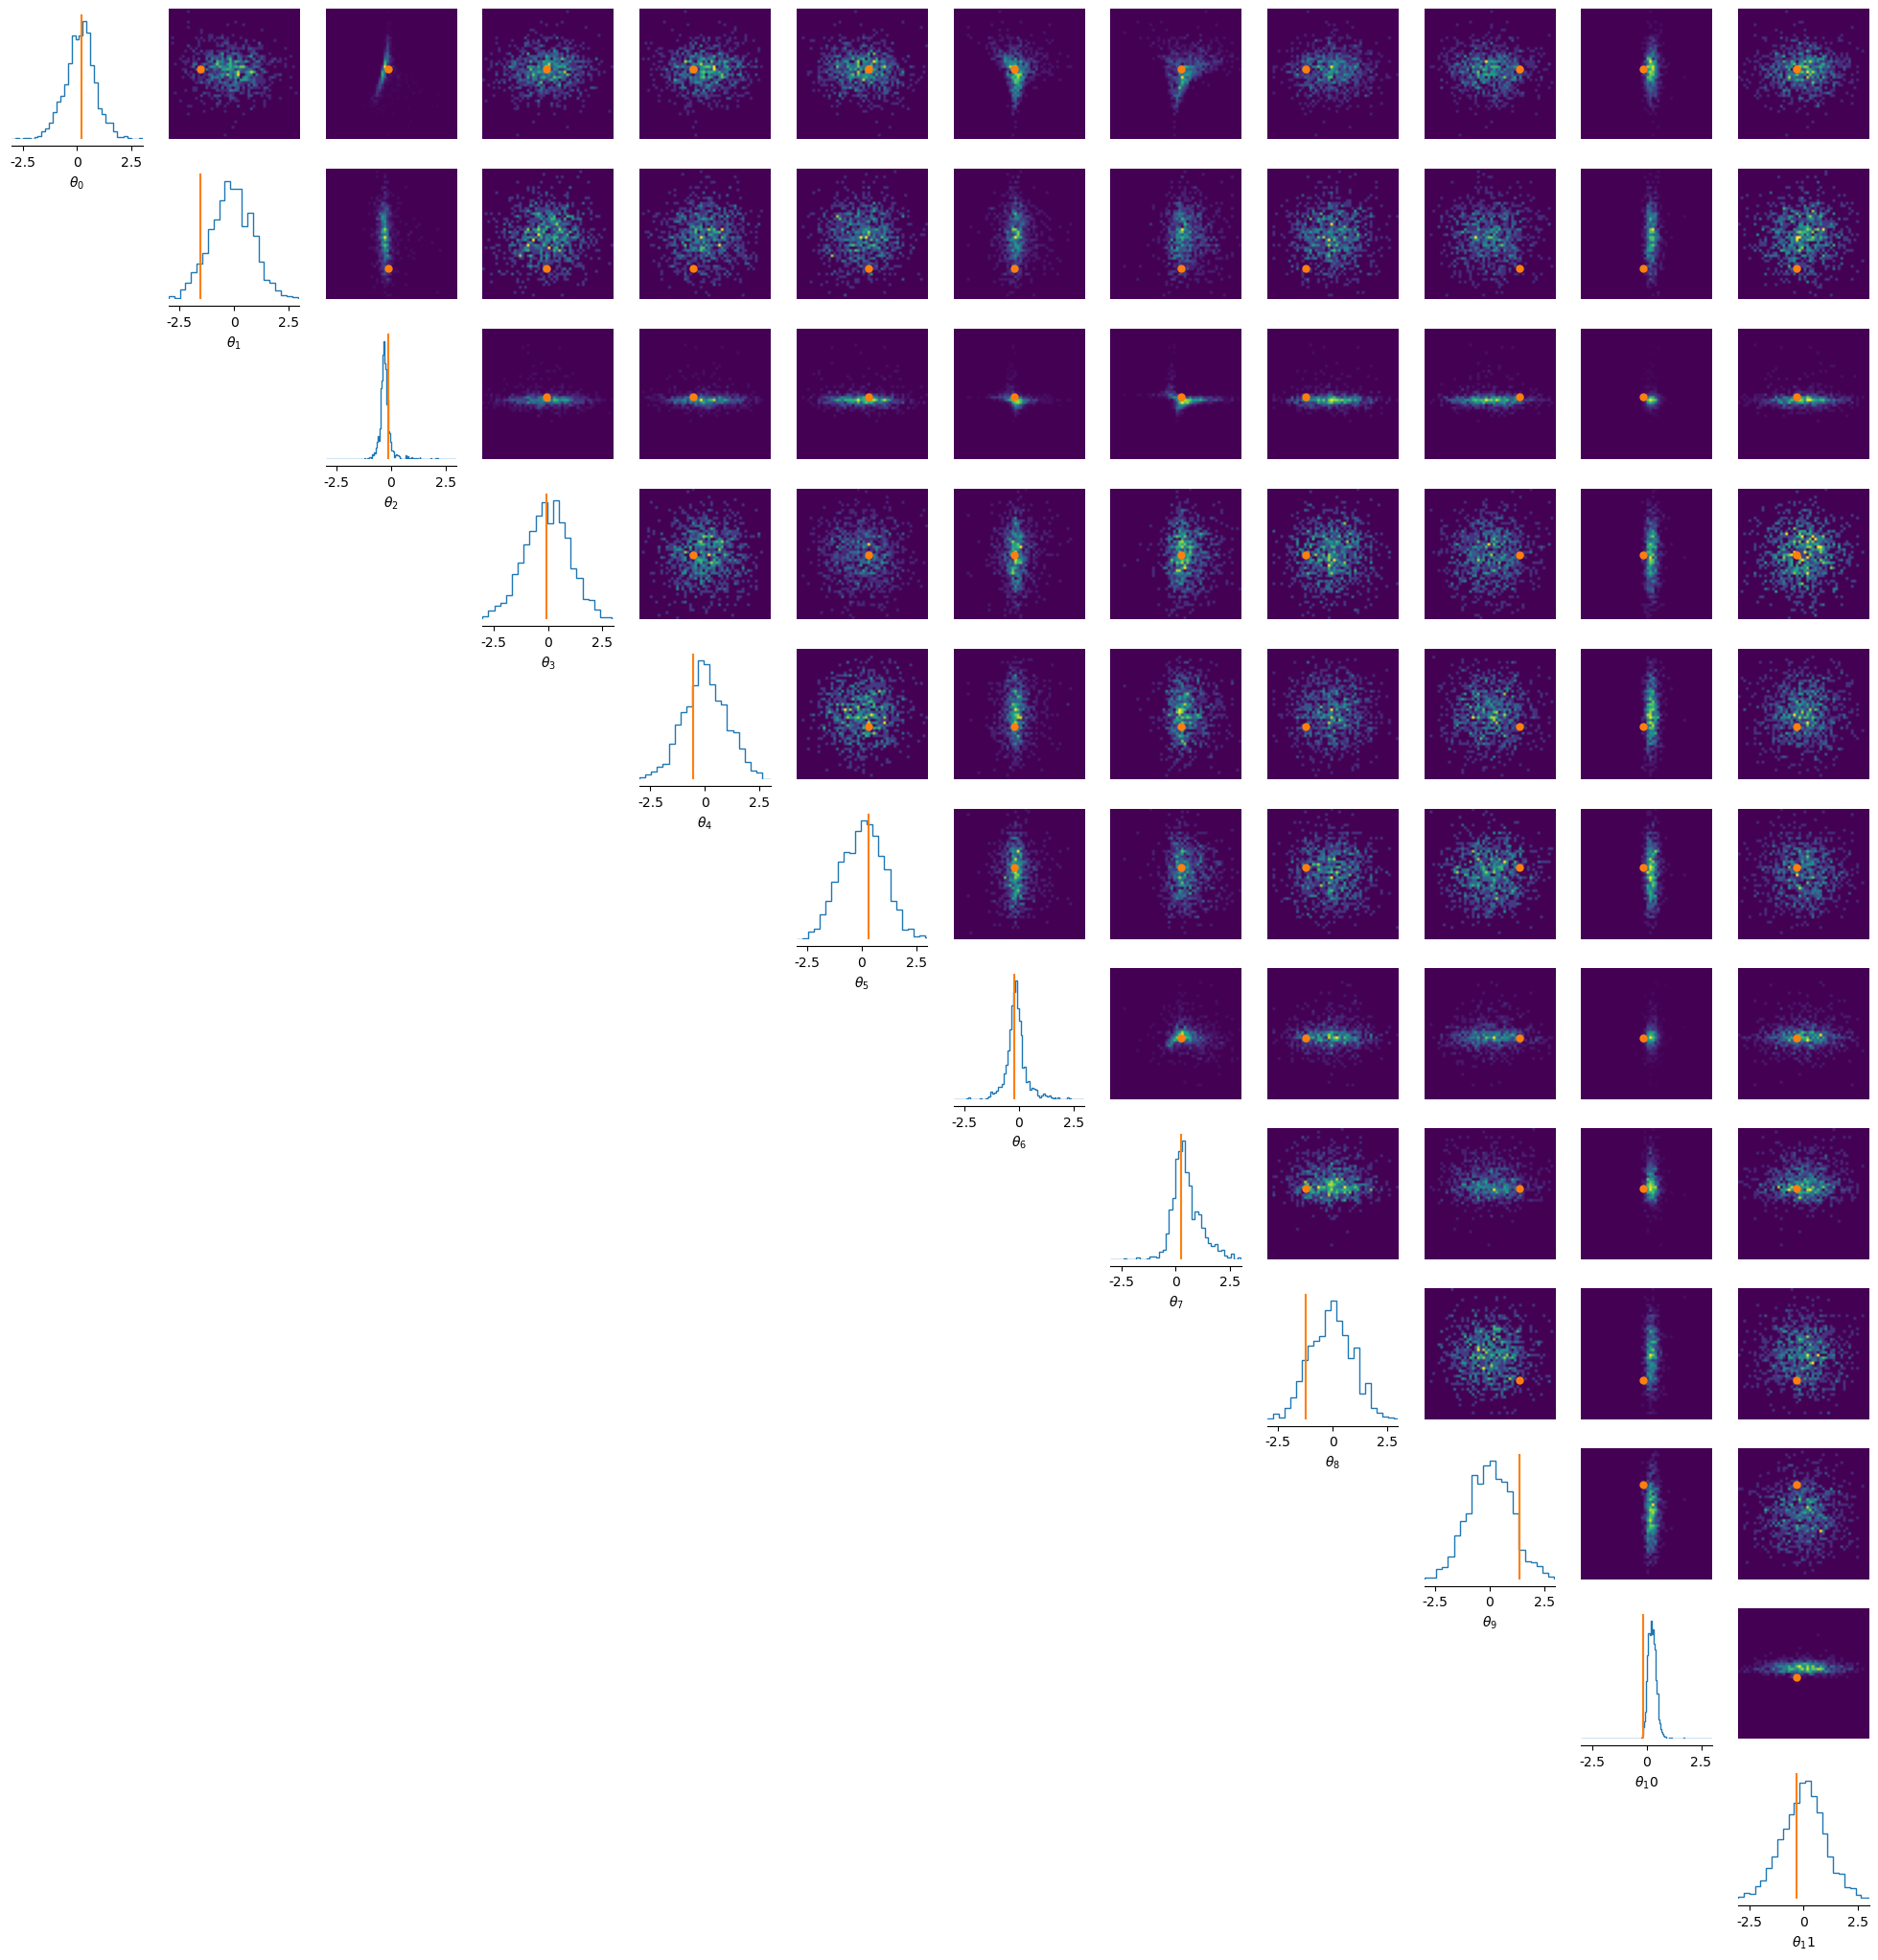

In [279]:
import sbi
from sbi.analysis.plot import pairplot

_ = pairplot(thetas_post, points=[thetas[idx],], limits=[[-3,3]*100], labels=[f'$\\theta_{i}$' for i in range(100)], figsize=(25, 25))

In [280]:
def posterior_pred(theta,rng):
    return sim_type.from_theta(theta, model_mask=mask[idx]).signal(acquisition_scheme(acq.bvals[idx], acq.bvecs[idx]), rng=rng)

posterior_preds = jax.vmap(posterior_pred)(thetas_post, jax.random.split(jax.random.key(0), 1024))

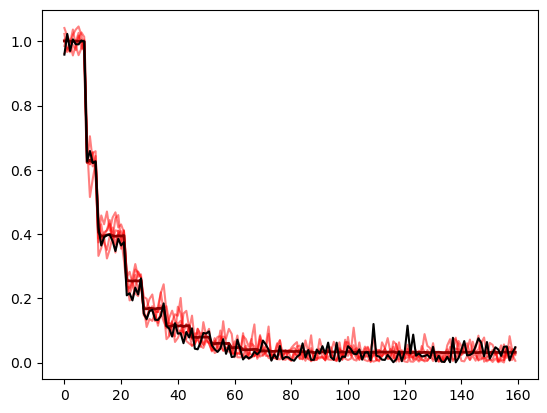

In [281]:
_ = plt.plot(posterior_preds[:5].T, label="posterior pred", color="red", alpha=0.5)
_ = plt.plot(posterior_preds.mean(0).T, label="posterior pred mean", color="darkred", linewidth=2)
_ = plt.plot(x_os[idx], label="data", color="black")

In [11]:
from dipy.data import get_fnames
from dipy.io.gradients import read_bvals_bvecs
from dipy.io.image import load_nifti
hardi_fname, hardi_bval_fname, hardi_bvec_fname = get_fnames(name="stanford_hardi")

data, affine = load_nifti(hardi_fname)

bvals, bvecs = read_bvals_bvecs(hardi_bval_fname, hardi_bvec_fname)


In [12]:
sum(bvals==0)

np.int64(10)

In [13]:
from dipy.segment.mask import median_otsu

datamask, mask = median_otsu(
    data, vol_idx=range(10, 50), median_radius=3, numpass=1, autocrop=True, dilate=2
)
b0_mask = bvals == 0

In [14]:
# Data sub
S0 = np.mean(datamask[..., b0_mask], -1)
data_norm = datamask / S0[..., None]
x_o = data_norm[13:43, 44:74, 28:29].squeeze()
S_o = S0[13:43, 44:74, 28:29].squeeze()


/tmp/ipykernel_3198/3122232576.py:3: RuntimeWarning: divide by zero encountered in divide
  data_norm = datamask / S0[..., None]
/tmp/ipykernel_3198/3122232576.py:3: RuntimeWarning: invalid value encountered in divide
  data_norm = datamask / S0[..., None]


Text(0.5, 1.0, 'HCP coronal slice B0 with ROI')

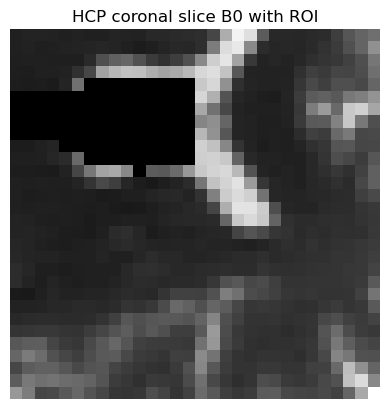

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
%matplotlib inline

fig, ax = plt.subplots(1)
ax.imshow(S_o, cmap='gray', origin='lower')
ax.set_axis_off()
ax.set_title('HCP coronal slice B0 with ROI')

In [16]:
acq = acquisition_scheme(jnp.array(bvals), jnp.array(bvecs))

In [17]:
sample_mask_per_x= jax.jit(jax.vmap(lambda k, x: model.sample_mask(k, acq.bvals, acq.bvecs, x), in_axes=(0,0)))
x_o_flat = x_o.reshape(-1, x_o.shape[-1])

mask = sample_mask_per_x(jax.random.split(jax.random.key(0), x_o_flat.shape[0]), x_o_flat).astype(jnp.float32)
for i in range(1,100):
    mask += sample_mask_per_x(jax.random.split(jax.random.key(i), x_o_flat.shape[0]), x_o_flat).astype(jnp.float32)
p_models = mask / 100

(0, 1, 2, 3, 4)


In [289]:
30*30

900

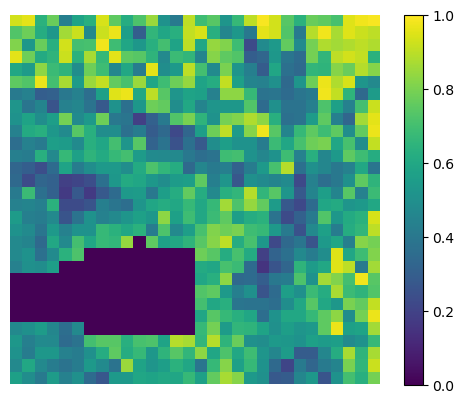

In [290]:
fig, ax = plt.subplots(1)
l = ax.imshow(p_models[:,0].reshape(30,30), vmin=0,vmax=1.)
ax.set_axis_off()
plt.colorbar(l)

In [291]:
model_mask = jnp.array([True, True, False, True, False], dtype=jnp.bool)
sample_theta_per_x = jax.jit(jax.vmap(lambda k, x: model.sample_theta(k, acq.bvals, acq.bvecs, x, model_mask, num_steps=64, max_noise=40), in_axes=(0,0)))

thetas = []
for i in range(10):
    thetas.append(sample_theta_per_x(jax.random.split(jax.random.key(i), x_o_flat.shape[0]), x_o_flat))


(0, 1, 2, 3, 4)


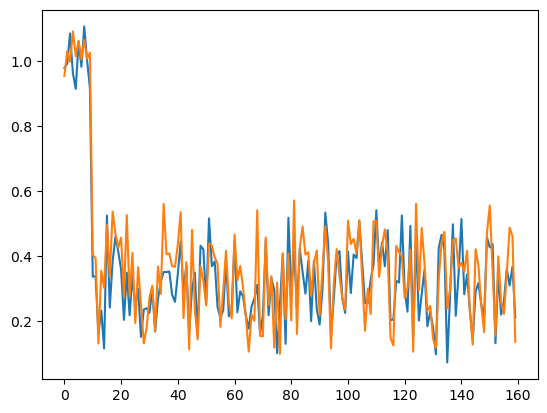

In [292]:

def sim_theta(key, theta):
    simulator = sim_type.from_theta(theta, model_mask=model_mask)
    x_pred = simulator.signal(acq, rng=key)
    return x_pred

x_preds = jax.vmap(sim_theta)(jax.random.split(jax.random.key(0), thetas[0].shape[0]), thetas[3])

plt.plot(x_o_flat[13], label="data")
plt.plot(x_preds[13], label="pred")

In [293]:
def to_params_dict(theta):
    simulator = sim_type.from_theta(theta, model_mask=model_mask)
    fractions = simulator.model_fractions
    components = simulator.model_compartments
    noise = simulator.noise_compartments

    com_params = [c.params for c in components]
    noise_params = [n.params for n in noise]
    return {"fractions": fractions, "components": com_params, "noise": noise_params}

In [294]:
from dmri.utils.dmriutils import unitsphere_to_cartesian


all_params = jax.vmap(to_params_dict)(thetas[0])
frac = all_params["fractions"]
lam_iso = all_params["components"][0]["lam"]
lam_par = all_params["components"][1]["lam_par"]
mu = all_params["components"][1]["mu"]
direction = jax.vmap(unitsphere_to_cartesian)(mu)


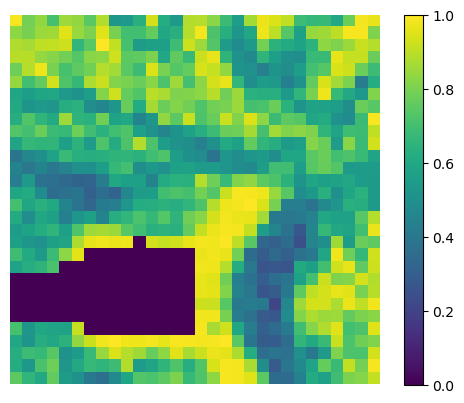

In [295]:
fig, ax = plt.subplots(1)
l = ax.imshow(frac[:,0].reshape(30,30), vmin=0,vmax=1.)
ax.set_axis_off()
plt.colorbar(l)

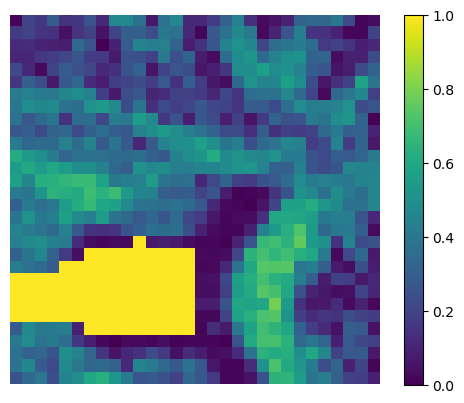

In [296]:
fig, ax = plt.subplots(1)
l = ax.imshow(frac[:,1].reshape(30,30), vmin=0,vmax=1.)
ax.set_axis_off()
plt.colorbar(l)

In [297]:


all_params = jax.vmap(to_params_dict)(thetas[0])
frac = all_params["fractions"]
lam_iso = all_params["components"][0]["lam"]
lam_par = all_params["components"][1]["lam_par"]
mu = all_params["components"][1]["mu"]
direction = jax.vmap(unitsphere_to_cartesian)(mu)

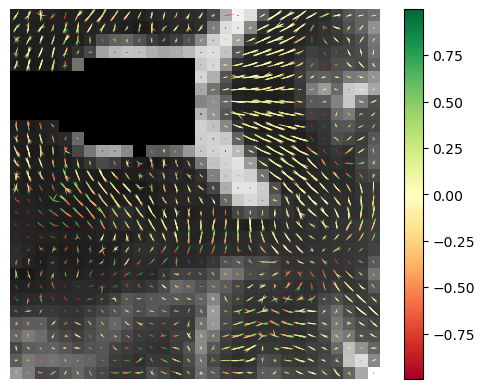

In [298]:
fig, ax = plt.subplots(1)
ax.imshow(S_o.reshape(30, 30), cmap='gray', origin='lower')


for i in range(10):
    # For example, use the first sample in thetas
    all_params = jax.vmap(to_params_dict)(thetas[i])
    frac    = all_params["fractions"]
    lam_par = all_params["components"][1]["lam_par"]
    mu      = all_params["components"][1]["mu"]

    # Convert unit sphere directions to 3D cartesian coordinates.
    direction = jax.vmap(unitsphere_to_cartesian)(mu)
    # Compute 2D projection using the first two components.
    direction_2d = direction[:, :2] * frac[:, 1][:, None] * (lam_par[:, None] > 0)

    # Use the third component (z) as the color code.
    colors = direction[:, 2]

    # Create a grid for quiver
    X, Y = np.meshgrid(np.arange(30), np.arange(30))
    q = ax.quiver(X, Y, direction_2d[:, 0].reshape(30, 30),
                  direction_2d[:, 1].reshape(30, 30),
                  colors.reshape(30, 30), cmap="RdYlGn", scale=25, headwidth=0, headlength=0)
plt.colorbar(q)
ax.set_axis_off()
plt.show()

In [99]:
from dipy.data import get_sphere, gradient_table
from dipy.reconst.dti import TensorModel


gtab = gradient_table(bvals, bvecs=bvecs)
sphere = get_sphere(name="repulsion724")

tenmodel = TensorModel(gtab)
tenfit = tenmodel.fit(datamask[13:43, 44:74, 28:29])

from dipy.viz import actor, window

# Enables/disables interactive visualization
interactive = False

scene = window.Scene()

evals = tenfit.evals
evecs = tenfit.evecs

In [311]:
# Ball and Zeppelins

model_mask = jnp.array([True, True, True, True, False], dtype=jnp.bool)
sample_theta_per_x = jax.jit(jax.vmap(lambda k, x: model.sample_theta(k, acq.bvals, acq.bvecs, x, model_mask, num_steps=128, max_noise=40), in_axes=(0,0)))

thetas = []
for i in range(6):
    thetas.append(sample_theta_per_x(jax.random.split(jax.random.key(i), x_o_flat.shape[0]), x_o_flat))

def sim_theta(key, theta):
    simulator = sim_type.from_theta(theta, model_mask=model_mask)
    x_pred = simulator.signal(acq, rng=key)
    return x_pred


(0, 1, 2, 3, 4)


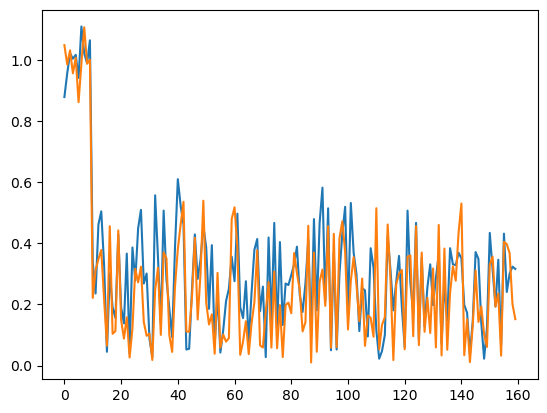

In [316]:
x_preds = jax.vmap(sim_theta)(jax.random.split(jax.random.key(0), thetas[0].shape[0]), thetas[3])

i = 400
plt.plot(x_o_flat[i], label="data")
plt.plot(x_preds[i], label="pred")

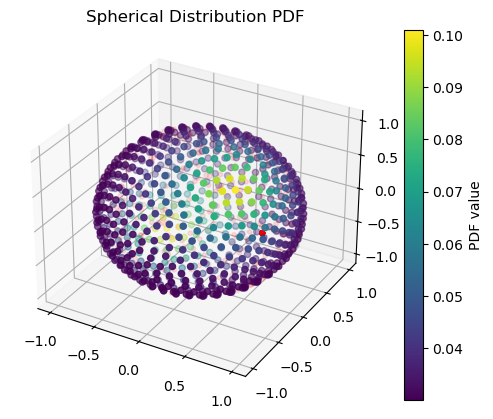

In [317]:
%matplotlib inline
fod = sim_type.from_theta(thetas[0][13], model_mask=model_mask).to_fod()
fod.viz(n_samples=5_00)

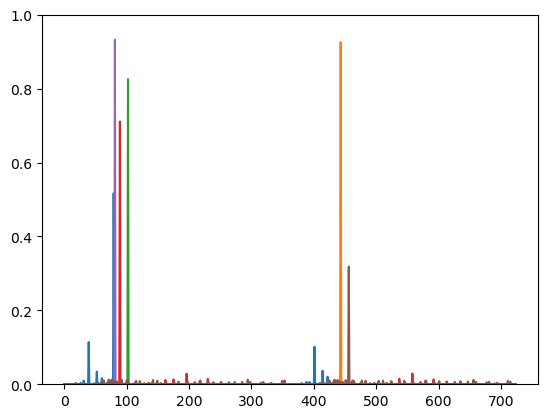

In [318]:

for i in range(len(thetas)):
    fod = sim_type.from_theta(thetas[i][400], model_mask=model_mask).to_fod()
    pmf = fod.to_pmf()
    plt.plot(pmf)
    plt.ylim(0, 1)

In [319]:
def to_fod_sample(theta, rng):
    simulator = sim_type.from_theta(theta, model_mask=model_mask)
    fod = simulator.to_fod()
    return fod.fractions, fod.sample(rng, shape=(200,))

IndexError: list index out of range

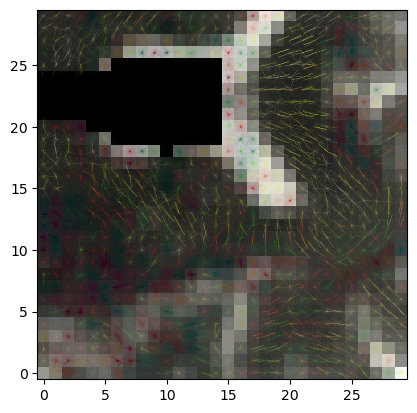

In [320]:
fig, ax = plt.subplots(1)
ax.imshow(S_o.reshape(30, 30), cmap='gray', origin='lower')

for i in range(6):
    theta = thetas[i]
    fractions, directions = jax.vmap(to_fod_sample)(theta, jax.random.split(jax.random.key(i), theta.shape[0]))
    for i in range(40):
        direction_2d = directions[:, i,:2]

        # Use the third component (z) as the color code.
        colors = direction[:, 2]

        # Create a grid for quiver
        X, Y = np.meshgrid(np.arange(30), np.arange(30))
        q = ax.quiver(X, Y, direction_2d[:, 0].reshape(30, 30),
                    direction_2d[:, 1].reshape(30, 30),
                    colors.reshape(30, 30), cmap="RdYlGn", scale=25, headwidth=0, headlength=0, alpha=0.01)
ax.set_axis_off()
plt.show()

In [8]:
from dipy.core.gradients import gradient_table
from dipy.data import default_sphere, get_fnames, small_sphere
from dipy.direction import ProbabilisticDirectionGetter, peaks_from_model
from dipy.io.gradients import read_bvals_bvecs
from dipy.io.image import load_nifti, load_nifti_data
from dipy.io.stateful_tractogram import Space, StatefulTractogram
from dipy.io.streamline import save_trk
from dipy.reconst.csdeconv import ConstrainedSphericalDeconvModel, auto_response_ssst
from dipy.reconst.shm import CsaOdfModel
from dipy.tracking import utils
from dipy.tracking.local_tracking import LocalTracking
from dipy.tracking.stopping_criterion import ThresholdStoppingCriterion
from dipy.tracking.streamline import Streamlines
from dipy.viz import actor, colormap, has_fury, window

# Enables/disables interactive visualization
interactive = False

hardi_fname, hardi_bval_fname, hardi_bvec_fname = get_fnames(name="stanford_hardi")
label_fname = get_fnames(name="stanford_labels")

data, affine, hardi_img = load_nifti(hardi_fname, return_img=True)
labels = load_nifti_data(label_fname)
bvals, bvecs = read_bvals_bvecs(hardi_bval_fname, hardi_bvec_fname)
gtab = gradient_table(bvals, bvecs=bvecs)

seed_mask = labels == 2
white_matter = (labels == 1) | (labels == 2)
seeds = utils.seeds_from_mask(seed_mask, affine, density=1)

response, ratio = auto_response_ssst(gtab, data, roi_radii=10, fa_thr=0.7)
csd_model = ConstrainedSphericalDeconvModel(gtab, response, sh_order_max=6)
csd_fit = csd_model.fit(data, mask=white_matter)

In [9]:
csa_model = CsaOdfModel(gtab, sh_order_max=6)
gfa = csa_model.fit(data, mask=white_matter).gfa
stopping_criterion = ThresholdStoppingCriterion(gfa, 0.25)

In [10]:
fod = csd_fit.odf(sphere)
pmf = fod.clip(min=0)
prob_dg = ProbabilisticDirectionGetter.from_pmf(
    pmf, max_angle=30.0, sphere=sphere
)
streamline_generator = LocalTracking(
    prob_dg, stopping_criterion, seeds, affine, step_size=0.5
)
streamlines = Streamlines(streamline_generator)
sft = StatefulTractogram(streamlines, hardi_img, Space.RASMM)
save_trk(sft, "tractogram_probabilistic_dg_pmf.trk")


scene = window.Scene()
scene.add(actor.line(streamlines, colors=colormap.line_colors(streamlines)))
window.record(
    scene=scene, out_path="tractogram_probabilistic_dg_pmf.png", size=(800, 800)
)

NameError: name 'sphere' is not defined

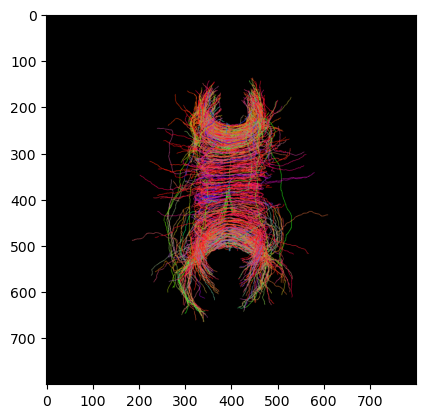

In [326]:
img = plt.imread("tractogram_probabilistic_dg_pmf.png")
plt.imshow(img)

In [18]:
x_o_full = np.nan_to_num(data_norm)

In [19]:
x_o_full_flat = x_o_full.reshape(-1, x_o_full.shape[-1])

In [31]:
model_mask = jnp.array([True, True, True, True, False], dtype=jnp.bool)
def sample_thetas(key, x):
    thetas = model.sample_theta(key, acq.bvals, acq.bvecs, x, model_mask, num_steps=32, max_noise=20)
    return thetas

In [32]:
keys = jax.random.split(jax.random.key(0), 1_00)
pmf1 = jax.vmap(sample_thetas)(keys, x_o_full_flat[:1_00])

2025-02-23 17:50:14.186026: W external/xla/xla/tsl/framework/bfc_allocator.cc:501] Allocator (GPU_0_bfc) ran out of memory trying to allocate 3.91MiB (rounded to 4096000)requested by op 
2025-02-23 17:50:14.186246: W external/xla/xla/tsl/framework/bfc_allocator.cc:512] **************************************************************************************************xx
E0223 17:50:14.186269    3198 pjrt_stream_executor_client.cc:3045] Execution of replica 0 failed: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 4096000 bytes. [tf-allocator-allocation-error='']


ValueError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 4096000 bytes.